In [ ]:
# Import JAX and related libraries
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap
from jax.scipy.stats import gaussian_kde, multivariate_normal
# Use 64 bit precision for better numerical stability in ODE solvers
jax.config.update("jax_enable_x64", True)
# Flax
from flax import linen as nn
# Set random seed for reproducibility
key = jax.random.PRNGKey(0) 
# Optimisation
import optax

# Integration and ODE solvers
import diffrax
from diffrax import diffeqsolve, ODETerm, Tsit5, SaveAt

# Numpy
import numpy as np

# Statistics
import scipy.stats as stats
from scipy.special import inv_boxcox
import pandas as pd
import seaborn as sns

# Plotting
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Progress bar and timing
import time
from tqdm.auto import tqdm

# Add folder for figures
from pathlib import Path
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

### 1 parameter example

In [2]:
# Define scales and default number of steps for integration
UV_scale, IR_scale = 10**5, 91
t1 = jnp.log(IR_scale/UV_scale)
ODE_steps = 1000
dt = t1/ODE_steps
saveat = SaveAt(ts=jnp.linspace(0, t1, ODE_steps))

# RG parameters
beta1 =  41/(12*jnp.pi)

# beta function for the coupling alpha1
def beta_alpha1(t, alpha1, _):
    return beta1 * alpha1**2

# Solves RG equation for alpha1 given an initial value in the UV, and returns the solution at the specified time points
def solve_rg(UVBC):
    return diffeqsolve(ODETerm(beta_alpha1), Tsit5(), t0=0, t1=t1, dt0=dt, y0=UVBC, saveat=saveat)
    
### Determine the RG flow of the distribution, given a distribution at the UV scale ###

# Monte-Carlo sampling of the distribution at the UV scale
def sample_uv(N, mu, sigma, key):
    key, subkey = jax.random.split(key)
    return jax.random.multivariate_normal(subkey, mu, sigma, shape=(N,)), key

# RG evolves samples from UV to IR scale
@jit
def run_rg(alpha0_samples):
    return vmap(lambda a0: solve_rg(a0).ys)(alpha0_samples)

# Sample from the UV distribution. Take samples of the coupling g then convert to alpha to avoid negative alphas
N = 2000
g_0, key = sample_uv(N, jnp.array([0]), jnp.array([[1]]), key)
g_0 = g_0.squeeze(-1)       # Changes Shape (N,1) → (N,)
alpha_0 = g_0**2/(4*jnp.pi)
# IR samples obtained by running RG flow on the UV samples
alpha_ir = run_rg(alpha_0)

# Use analytical expression for the RG flow to determine the IR distribution from the UV distribution, to compare to the numerical result
alpha_ir_analytical = alpha_0/(1 - beta1*t1*alpha_0)

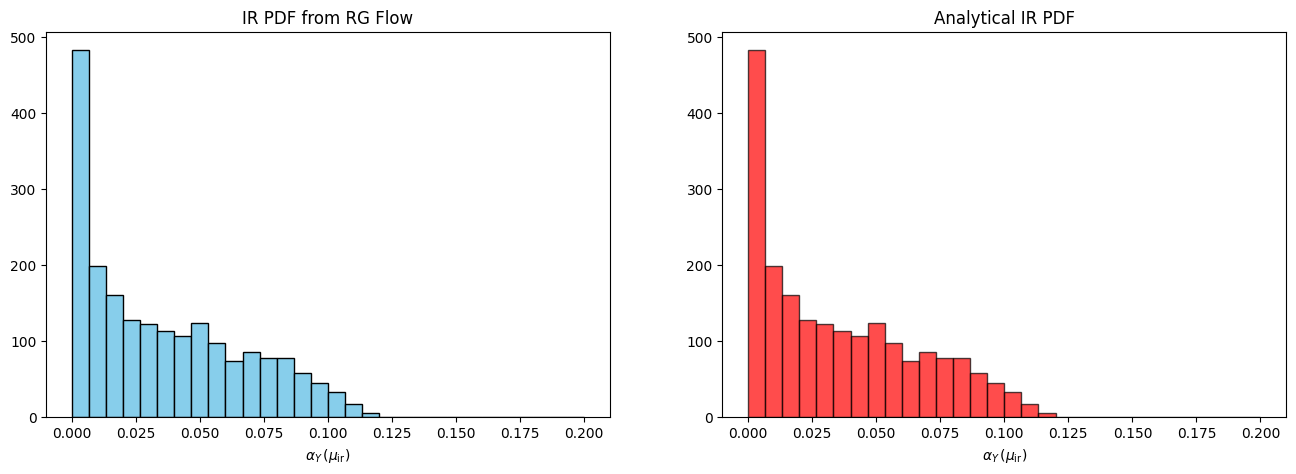

In [3]:
# Plot histograms of the numerically and analytically derived PDFs
fig, ax  = plt.subplots(1, 2, figsize=(16, 5))
ax[0].hist(alpha_ir[:, -1], bins=30, color='skyblue', range = (0, .2), edgecolor='black')
ax[0].set_title('IR PDF from RG Flow')
ax[0].set_xlabel(r"$\alpha_Y \, (\mu_{\rm ir})$")
ax[1].hist(alpha_ir_analytical, bins=30, color='red', range = (0, .2), edgecolor='black', alpha=0.7)
ax[1].set_title('Analytical IR PDF')
ax[1].set_xlabel(r"$\alpha_Y \, (\mu_{\rm ir})$")
plt.savefig(fig_dir / "pdf_comparison.png")
plt.show()

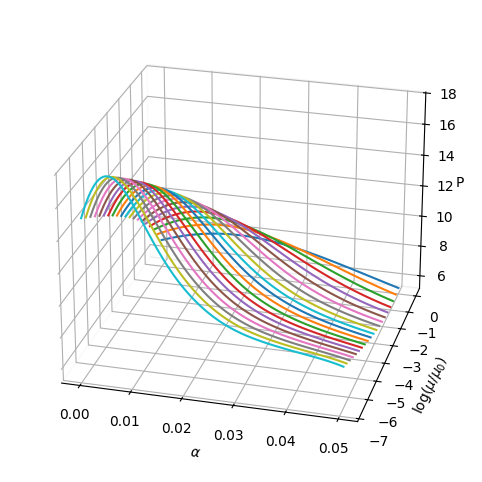

In [4]:
### Here we will show the evolution of the pdf along the RG trajectory ###

# Define points in alpha space where we want to evaluate pdf at
eval_points = jnp.linspace(0, .05, 100)     # Could also use: jnp.linspace(0, alpha_ir[:, -1].max(), 100)

# At every `time' step, perform a Gaussian Kernel Density Estimate (KDE) to fit to the data, then evaluate at eval_points
def kde_at_timestep(timestep_samples): return gaussian_kde(timestep_samples)(eval_points)

# Returns a grid of pdf values as a function of alpha for each t-step
densities = vmap(kde_at_timestep)(alpha_ir.T)  # (ODE_steps, 100)

# Subsample timesteps for clarity and create grid, we end up with grids of alpha and t values of size (100, ODE_steps/stride)
t_points = jnp.linspace(0, t1, ODE_steps)
stride = 50
X, T = jnp.meshgrid(eval_points, t_points[::stride], indexing='ij') 

# Make 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Rotate so y-axis is more square to the front
ax.view_init(elev=25, azim=-75)

# White background
fig.patch.set_facecolor('white')
ax.xaxis.pane.set_facecolor('white')
ax.yaxis.pane.set_facecolor('white')
ax.zaxis.pane.set_facecolor('white')

# Plotting
for i in range(0, ODE_steps, stride):
    ax.plot(eval_points, jnp.full_like(eval_points, t_points[i]), densities[i],  alpha=1, linewidth = 1.5)

# Axes labels
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel(r'$\log (\mu / \mu_0) $')
ax.set_zlabel('P', labelpad=-2)
plt.savefig(fig_dir / "pdf_evolution_underRG.png")
plt.show()

### SM parameter space

In [2]:
# Define scales and default number of steps for integration
UV_scale, IR_scale = 10**18, 91
t1 = float(jnp.log(IR_scale/UV_scale))
ODE_steps = 1000
dt = t1/ODE_steps
# saveat = SaveAt(ts=jnp.linspace(0, t1, ODE_steps))
saveat = SaveAt(t1=True)        ### Use this if doing ML training — otherwise use the above line to save at all timesteps
n_params = 7

# RG parameters
b1, b2, b3, c =  41/(96*jnp.pi**2), -19/(96*jnp.pi**2), -7/(16*jnp.pi**2), 1/(16*jnp.pi**2)

# Beta functions at one loop. The functional form is a mess but not that important
def beta_functions( params):
    [a1, a2, a3, lam, yt, yb, ytau] = params
    g1, g2, g3 = jnp.sqrt(4*jnp.pi*a1), jnp.sqrt(4*jnp.pi*a2), jnp.sqrt(4*jnp.pi*a3)
    beta_a1, beta_a2, beta_a3 = b1*a1/2, b2*a2/2, b3*a3/2
    beta_lam = c*(24*lam**2 - 6*yt**4 - 6*yb**4 - 2*ytau**4 + 0.375*(2*g2**4 + (g2**2 + g1**2)**2) - lam*(9*g2**2 + 3*g1**2 - 12*yt**2 - 12*yb**2 - 4*ytau**2)) 
    beta_yt = c*yt*(4.5*yt**2 + 1.5*yb**2 + ytau**2 - 2.25*g2 - 17*g1/12 - 8*g3)
    beta_yb = c*yb*(1.5*yt**2 + 4.5*yb**2 + ytau**2 - 2.25*g2 - 5*g1/12 - 8*g3)
    beta_ytau = c*ytau*(3*yt**2 + 3*yb**2 + 2.5*ytau**2 - 2.25*g2 - 15*g1/4)
    # 2-loop corrections
    beta_a1 += 2*a1*c**2 *((199*g1**2)/18 + (9*g2**2)/2 + (44*g3**2)/3 - (17*yt**2)/6 - yb**2/30 - ytau**2/10)
    beta_a2 += 2*a2*c**2 *((3*g1**2)/2 + (35*g2**2)/6 + 12*g3**2 - (3*yt**2)/2 - (3*yb**2)/2 - ytau**2/2)
    beta_a3 += 2*a3*c**2 *((11*g1**2)/6 + (9*g2**2)/2 - 26*g3**2 - 2*yt**2 - 2*yb**2)
    beta_lam += c**2*( (915*g2**6 - 289*g2**4*g1**2 - 559*g2**2*g1**4 - 379*g1**6)/48 + 30*yt**6 + 30*yb**6 + 10*ytau**6 - yt**4 * (8*g1**2/3 + 32*g3**2 + 3*lam + 6*yb**2) - yb**4 * (4*g1**2/3 + 32*g3**2 + 3*lam + 6*yt**2) - ytau**4 * (4*g1**2 + 3*lam))
    beta_lam += c**2* (lam * (-(73/8)*g2**4 + 39/4*g2**2*g1**2 + (629*g1**4)/24 +108*g2**2*lam + 36*g1**2*lam - 312*lam**2) + yt**2 * (-(9/4)*g2**4 + 21/2*g2**2*g1**2 - (19*g1**4)/4 + lam * ((45*g2**2)/2 + (85*g1**2)/6 + 80*g3**2 - 144*lam - 42*yb**2)) + yb**2 * (-(9/4)*g2**4 + 9/2*g2**2*g1**2 - (5*g1**4)/4 + lam * ((45*g2**2)/2 + (25*g1**2)/6 + 80*g3**2 - 144*lam - 42*yt**2)) + ytau**2 * (-(3/4)*g2**4 + 11/2*g2**2*g1**2 - (25*g1**4)/4 + lam * ((15*g2**2)/2 + (75*g1**2)/6 - 48*lam)))
    beta_yt += yt*c**2 *(-(23/4)*g2**4 - 0.75*g2**2*g1**2 + (1187*g1**4)/216 + 9*g2**2*g3**2 + 19/9*g1**2*g3**2 - 108*g3**4 + yt**2*((225*g2**2)/16 + (131*g1**2)/16 + 36*g3**2 - (11*yb**2)/4 - (9*ytau**2)/4) + yb**2*(-(1/4)*yb**2 + (5*ytau**2)/4 + 4*g3**2 + (99*g2**2)/16 + (7*g1**2)/48) + ytau**2*(-(9/4)*ytau**2 + (15*g2**2)/8 + (25*g1**2)/8) + 6*(-2*yt**4 - 2*yt**2*lam + lam**2))
    beta_yb += yb*c**2 *(6*lam**2 - 108*g3**4 - (23*g1**4)/4 - (127*25*g1**4)/(600*9) + 9*g3**2*g2**2 + 31/9*g3**2*g1**2 - 9/4*g2**2*g1**2 + yt**2*(-(1/4)*yt**2 - (11*yb**2)/4 + (5*ytau**2)/4 + 4*g3**2 + (99*g2**2)/16 + (91*g1**2)/48) + yb**2*(-12*yb**2 - (9*ytau**2)/4 - 12*lam + 36*g3**2 + (225*g2**2)/16 + (79*g1**2)/16) + ytau**2*(-(9/4)*ytau**2 + (15*g2**2)/8 + (25*g1**2)/8))
    beta_ytau += ytau*c**2 *(6*lam**2 - (23*g2**4)/4 + (1371*25*g1**4)/(200*9) + 9/4*g2**2*g1**2 + yt**2*(-(27/4)*yt**2 + (3*yb**2)/2 - (27*ytau**2)/4 + 20*g3**2 + (45*g2**2)/8 + (17*5*g1**2)/(8*3)) + yb**2*(-(27/4)*yb**2 - (27*ytau**2)/4 + 20*g3**2 + (45*g2**2)/8 + (25*g1**2)/24) + ytau**2*(-3*ytau**2 - 12*lam + 165*g2**2 + (179*g1**2)/16))
    return jnp.array([beta_a1, beta_a2, beta_a3, beta_lam, beta_yt, beta_yb, beta_ytau])

# RG evolves both the couplings and the log-pdf, whose evolution is set by the divergence of beta functions
def full_dynamics(t, state, _):
    g = state[:-1]        # coupling values
    
    # Velocity field: just the beta functions
    beta = beta_functions(g)
    
    # Divergence of beta functions via JAX autodiff
    div_beta = jnp.trace(jax.jacfwd(beta_functions)(g))
    
    # Log-probability evolution
    d_log_p = -div_beta
    
    return jnp.append(beta, d_log_p)

# Solves RG equations for couplings and pdf given an initial condition in the UV
def RG_evolution(params0, log_p0, t0=0, t1=t1, dt0=dt, saveat = saveat):
    initial_state = jnp.append(params0, log_p0)
    
    solution = diffeqsolve( ODETerm(full_dynamics), solver=Tsit5(), t0=t0, t1=t1, dt0=dt0, y0=initial_state, saveat=saveat)
    
    # solution.ys has shape (ODE_steps, n_params + 1)
    params_IR = solution.ys[:, :-1]     # shape (ODE_steps, n_params) — all timesteps, couplings only
    log_p_IR = solution.ys[:, -1]       # shape (ODE_steps,)  — all timesteps, log-prob only
    
    return params_IR, log_p_IR
    
# Monte-Carlo sampling of the distribution at the UV scale. This is the same as above
def sample_uv(N, mu, sigma, key):
    key, subkey = jax.random.split(key)
    return jax.random.multivariate_normal(subkey, mu, sigma, shape=(N,)), key

# RG evolves samples from UV to IR scale
run_rg = jit(vmap(RG_evolution, in_axes=(0, 0)))

# Sample from the UV distribution and run into the IR
# N = 800
# means, cov_mat = jnp.zeros(n_params), jnp.eye(n_params)
# params0, key = sample_uv(N, means, cov_mat, key)
# log_p0 = multivariate_normal.logpdf(params0, mean=means, cov=cov_mat)
# params_IR, log_p_IR = run_rg(params0, log_p0)

## Constructing the training data

In [36]:
# First step is to generate a random set of UV distributions to sample from
# Number of distributions we will sample from and the number of samples per distribution. N_distributions x N_samples gives total size of training set. Want large N_distributions to avoid overfitting
N_distributions, N_samples = 10000, 200

key, subkey1, subkey2 = jax.random.split(key, 3)

# Pick some mean values from varying around the SM values at the UV scale (obtained by inverting the RG flow)
# We could consider a more general sampling to learn an arbitrary distribution in the UV but this will be sufficient here
# Parmaters at the EW scale
central_values_EW = jnp.array([0.357**2/(4*jnp.pi), 0.652**2/(4*jnp.pi), 1.221**2/(4*jnp.pi), 0.126, 0.950, 0.016, 0.01])
# Parmaters at the UV scale
SM_flow, _ = RG_evolution(central_values_EW, 0, t0=t1, dt0 = -dt, t1=0.0)
central_values_UV = SM_flow[-1]

# Sample to get random set of means, logarithmically distributed around these central values
def sample_random_mean(key):
    # Sample means in log space to ensure positivity of couplings and to explore the UV parameter space multiplicatively rather than additively
    log_mean = jnp.log(central_values_UV) + 0.5*jax.random.normal(key, shape=central_values_UV.shape)
    return jnp.exp(log_mean)        # Re-exponentiate

keys = jax.random.split(subkey1, N_distributions)
uv_means = vmap(sample_random_mean)(keys)
log_uv_means = jnp.log(uv_means)

# Generates random Cholesky matrices (lower traingular matrices) that can be used to construct a covariance matrix 
# This is sufficient for a conditioning vector and reduces the number of parameters in the flow network
def sample_random_chol(key, n_params, scale=.5):
    # Generate random matrix
    L = jax.random.normal(key, (n_params, n_params)) * scale
    # Zero out upper triangle
    L = jnp.tril(L)
    scaling = jnp.array([1.5, 1.0, 1.0, 0.3, 0.3, 0.5, 0.5])    # scaling reduces the spread in higgs quartic and top yukawa to avoid runaway behaviour
    L = L * scaling[None, :]
    # Ensure positive diagonal so matrix is positive definite
    L = L.at[jnp.diag_indices(n_params)].set(jnp.abs(jnp.diag(L)) + 1e-3)  # Add small value to ensure positivity, scaled by central values
    return L 

# Generate N_distributions x random covariance matrices
keys = jax.random.split(subkey2, N_distributions)
uv_chols = vmap(sample_random_chol, in_axes=(0, None))(keys, n_params)

# Generate conditioning vectors for each UV distribution
def make_cond(means, L):
    # Extracts just the lower triangular components of L
    chol_elements = L[jnp.tril_indices(len(means))]
    return jnp.concatenate([means, chol_elements])

# The conditioning vector concatenates the log-means and the lower triangular elements of the Cholesky factor L, where Sigma = L @ L.T is the UV covariance.
# Using L rather than Sigma reduces the number of conditioning parameters from n^2 to n*(n+1)/2, plus n for the means
conds = vmap(make_cond)(log_uv_means, uv_chols)  # (N_distributions, cond_dim = n(n+1)/2 + n = n(n+3)/2

Next we take samples from the UV distributions and RG-evolve them into the IR. This is the most costly part as it involves solving the ODEs many times. After doing so we apply a Box-Cox transformation to the IR data to make the training and test data more Gaussian

In [37]:
# Generate IR samples for each UV distribution
def generate_ir_samples(key, log_uv_mean, L):
    uv_cov = L @ L.T
    # Sample from UV distribution in log space
    log_uv_samples = jax.random.multivariate_normal(key, log_uv_mean, uv_cov, shape=(N_samples,))
    # Exponentiate to get physical couplings — guaranteed positive
    uv_samples = jnp.exp(log_uv_samples)
    # log_p0 tracks the log-probability under the UV distribution, including the log-Jacobian correction for the exp transform (log|J| = -sum log g).
    # This is passed to run_rg for potential analytical use (cf. Eichhorn & Held 2025) but discarded here since only the IR coupling values are needed for ML training.
    log_p0 = multivariate_normal.logpdf(log_uv_samples, mean=log_uv_mean, cov=uv_cov) - jnp.sum(log_uv_samples, axis=1)  # subtract log|J| = sum of log g
    # RG evolve to IR 
    params_traj, _ = run_rg(uv_samples, log_p0)

    return params_traj[:, -1, :].squeeze()  

# Generate keys for each distribution
key, subkey3 = jax.random.split(key)
sample_keys = jax.random.split(subkey3, N_distributions)

# Vectorise over distributions
ir_samples = vmap(generate_ir_samples)(sample_keys, log_uv_means, uv_chols)
# shape: (N_distributions, N_samples, n_params)

# Remove samples with large values or nans/infs, or where alpha's are negative
def valid(samples):
    valid = (
        jnp.isfinite(samples).all(axis=1) &  # no nans or infs
        (jnp.abs(samples) < threshold).all(axis=1) # no large values
    )
    return samples[valid]
# The main issue is there are runaway directions where the higgs quartic becomes large and negative (sourced by large values of the yukawa couplings)
x_list, conds_list, valid_indices = [], [], []
threshold = 5       # Sets maximum absolute value of couplings
for i in range(N_distributions):
    samples = ir_samples[i]  # (N_samples, n_params)
    samples_valid = valid(samples)
    if len(samples_valid) == 0:
        continue
    x_list.append(samples_valid)
    conds_list.append(np.tile(conds[i], (len(samples_valid), 1)))
    valid_indices.append(i)  # track valid indices
    
# Print fraction of valid samples remaining after removing nans and large values
print(f"Fraction of valid samples: {sum(len(x) for x in x_list) / (N_distributions * N_samples):.3f}")

# Shuffle and split at the level of distributions, after filtering, before concatenating
n_dists = len(x_list)
key, subkey4 = jax.random.split(key)
perm = np.array(jax.random.permutation(subkey4, n_dists))
x_list = [x_list[i] for i in perm]
conds_list = [conds_list[i] for i in perm]

split = int(0.8 * n_dists)

x_train = jnp.array(np.concatenate(x_list[:split], axis=0))
x_test  = jnp.array(np.concatenate(x_list[split:], axis=0))
conds_train = jnp.array(np.concatenate(conds_list[:split], axis=0))
conds_test  = jnp.array(np.concatenate(conds_list[split:], axis=0))

# Implements a Box-Cox transform on all couplings except higgs quartic before training. This helps the network because the pdfs are highly non-Gaussian with long tails, and the transform makes them more Gaussian
# The `lambda' parameter of the Box-Cox transform is determined separately for each coupling based on the training data, and then applied to both training and test data to ensure consistency`
x_train_norm = np.array(x_train, dtype=np.float64)
x_test_norm = np.array(x_test, dtype=np.float64)
transform_lambdas = np.zeros(n_params)
for i in range(n_params):
    if i == 3:  # skip Higgs quartic — can be negative
        continue
    x_train_norm[:, i], transform_lambdas[i] = stats.boxcox(x_train_norm[:, i])
    x_test_norm[:, i] = stats.boxcox(x_test_norm[:, i], transform_lambdas[i])

x_train_norm = jnp.array(x_train_norm)
x_test_norm = jnp.array(x_test_norm)

# Normalise according to statistics of training data and conditioning vectors
x_mean = jnp.mean(x_train_norm, axis=0)
x_std = jnp.std(x_train_norm, axis=0) + 1e-8  
cond_mean = jnp.mean(conds_train, axis=0)
cond_std = jnp.std(conds_train, axis=0) + 1e-8

x_train_norm = (x_train_norm - x_mean) / x_std
x_test_norm = (x_test_norm - x_mean) / x_std
conds_train_norm = (conds_train - cond_mean) / cond_std
conds_test_norm = (conds_test - cond_mean) / cond_std

# Function to implement batching, after the entire training set has been used it reshuffles the batches
def get_batch(key, x, conds, batch_size):
    num_batches = x.shape[0] // batch_size
    while True:
        key, subkey5 = jax.random.split(key)
        shuffled_indices = jax.random.permutation(subkey5, x.shape[0])
        for i in range(num_batches):
            batch_indices = shuffled_indices[i*batch_size:(i+1)*batch_size]
            yield x[batch_indices], conds[batch_indices]


Fraction of valid samples: 0.827


Check statistics of the training data and range of IR parameter space being trained on

In [38]:
# Check range of IR parameter space being sampled
print("IR samples range:")
print("  min:", x_train.min(axis=0))
print("  max:", x_train.max(axis=0))
print("  std:", x_train.std(axis=0))

# Shows the effect of the box-cox transform on the skewness of the distributions
# The transform significantly reduces the skewness, making the distributions more Gaussian and easier for the flow to learn
param_names = [r'$\alpha_1$', r'$\alpha_2$', r'$\alpha_3$', r'$\lambda$', r'$y_t$', r'$y_b$', r'$y_\tau$']
for i, name in enumerate(param_names):
    print(f"Pre-transformed skewness in {name}: skewness={stats.skew(np.array(x_train[:,i])):.2f}, ", f"Post-transformed skewness in {name}: skewness={stats.skew(np.array(x_train_norm[:,i])):.2f}")

IR samples range:
  min: [ 6.82566553e-07  3.50885105e-06  4.24373308e-06 -4.99945274e+00
  9.43929837e-07  2.27931005e-08  3.04409211e-13]
  max: [0.88931469 0.7036788  0.84891084 4.99996439 4.23333193 4.19523563
 1.51299632]
  std: [0.02378645 0.03046162 0.14977916 0.91636451 0.85160558 0.31411455
 0.04372387]
Pre-transformed skewness in $\alpha_1$: skewness=15.11,  Post-transformed skewness in $\alpha_1$: skewness=0.03
Pre-transformed skewness in $\alpha_2$: skewness=2.83,  Post-transformed skewness in $\alpha_2$: skewness=0.03
Pre-transformed skewness in $\alpha_3$: skewness=1.73,  Post-transformed skewness in $\alpha_3$: skewness=-0.01
Pre-transformed skewness in $\lambda$: skewness=1.67,  Post-transformed skewness in $\lambda$: skewness=1.67
Pre-transformed skewness in $y_t$: skewness=0.93,  Post-transformed skewness in $y_t$: skewness=-0.08
Pre-transformed skewness in $y_b$: skewness=5.67,  Post-transformed skewness in $y_b$: skewness=-0.02
Pre-transformed skewness in $y_\tau$: 

## Define and train Flow model

Designing a conditional normalising flow to approximate the above, `exact' evolution. The input to the flow are the IR couplings, and the flow learns to map these parameters to a latent space variable which is drawn from an isotropic Gaussian. The parameters of the UV distribution (mean, covariance matrix) condition this map (i.e. there is a different map for each mean and covariance matrix). Once trained we can sample a normal distribution and input the parameters of an arbitrary UV distribution to reconstruct the IR distribution efficiently. Because using the trained network does not require you to solve ODEs to reconstruct the IR distribution it is faster to call, but doing so necessarily introduces some error


In [39]:
# Function which creates a neural network which maps input to output of size 2 * c_in
def make_network(c_in, d_hid = 64):
    return nn.Sequential([
        nn.Dense(d_hid),
        nn.leaky_relu,
        nn.Dense(d_hid), 
        nn.leaky_relu,
        nn.Dense(2 * c_in)  # outputs s and t concatenated
    ])


# Define Coupling Layer
class CouplingLayer(nn.Module):
    network : nn.Module  # NN to use in the flow for predicting mu and sigma
    mask : jnp.ndarray  # Binary mask where 0 denotes that the element should be transformed, and 1 not.
    c_in : int  # Number of input channels
    
    def setup(self):
        # Defines scaling factor as learnable parameter
        self.scaling_factor = self.param('scaling_factor', nn.initializers.zeros, (self.c_in,))

    def __call__(self, z, cond, ldj, reverse=False):

        # Apply network to masked input
        # The nonzero elements of z_in are passed to the network to determine the transformations s, t which are then applied to the nonzero elements of z - z_in
        z_in = z * self.mask
        nn_out = self.network(jnp.concatenate([z_in, cond], axis=-1))
        s, t = jnp.split(nn_out, 2, axis=-1)

        # Stabilize scaling output by applying tanh function - limits rescaling to be between +/- s_fac, where s_fac is learned
        s_fac = jnp.exp(self.scaling_factor)
        s = nn.tanh(s / s_fac) * s_fac

        # Mask outputs (only transform the second part), which means that only nonero elements of z - z_in are updates
        s = s * (1 - self.mask)
        t = t * (1 - self.mask)

        # Affine transformation. Keeps updated log determinant, ldj
        if not reverse:
            # Whether we first shift and then scale, or the other way round, is a design choice, and usually does not have a big impact
            z = (z + t) * jnp.exp(s)
            ldj += s.sum(axis=-1)
        else:
            # Exact inverse of forward step, used if reverse = True
            z = (z * jnp.exp(-s)) - t
            ldj -= s.sum(axis=-1)

        return z, ldj

# Define normalising flow which maps a base distribution to the IR distribution, with the map conditioned on the UV distribution
class RGFlow(nn.Module):
    c_in: int
    n_layers : int
    d_hid : int = 64

    # Sets up neural network by creating mask and coupling layers
    def setup(self):
        # Alternating mask
        mask = jnp.arange(self.c_in) % 2  # Alternating mask
        self.layers = [
            CouplingLayer(
                network=make_network(c_in=self.c_in, d_hid=self.d_hid),
                mask= jnp.roll(mask, i),     # Cyclically permutes the mask
                # mask=mask[jax.random.permutation(jax.random.fold_in(key, i), self.c_in)],       # Shuffles mask every layer
                c_in=self.c_in
            )
            for i in range(self.n_layers)
        ]

    def __call__(self, z, cond, ldj, reverse=False):
        layers = self.layers
        if reverse: layers = reversed(layers)

        # Applies layers sequentially and finds transformed variable and log of Jacobian determinant
        for layer in layers:
            z, ldj = layer(z, cond, ldj, reverse=reverse)
        # Returns transformed variable and log of Jacobian determinant
        return z, ldj
    
    # Returns log probability
    def log_prob(self, z, cond):
        z, ldj = self.__call__(z, cond, jnp.zeros(()))
        log_p_z = -0.5 * jnp.sum(z**2, axis=-1) - 0.5 * self.c_in * jnp.log(2 * jnp.pi)
        return log_p_z + ldj

Initialise model, defines loss function and optimiser parameters

In [40]:
# Initialises model with random parameters
model = RGFlow(c_in = n_params, n_layers = 6, d_hid = 64)
key, subkey6 = jax.random.split(key)
params = model.init(subkey6, x_train_norm[:1], conds_train_norm[:1], jnp.zeros(()))  # initialise with dummy input, the jnp.zeros(1) is a dummy for the ldj input

# Optimiser initialisation
optimiser = optax.adam(learning_rate=1e-3)
opt_state = optimiser.init(params)

# Loss function
@jax.jit
def loss_fn(params, x_IR, cond):
    log_probs = jax.vmap(lambda x, c: model.apply(params, x, c, method=model.log_prob))(x_IR, cond)
    return -jnp.mean(log_probs)

# Training step
@jax.jit
def train_step(params, opt_state, x_IR, cond):
    loss, grads = jax.value_and_grad(lambda p: loss_fn(p, x_IR, cond))(params)
    updates, opt_state_new = optimiser.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state_new

Training the model

In [41]:
train_steps = 200000
batch_generator = get_batch(key, x_train_norm, conds_train_norm, batch_size=512)
train_losses, test_losses = [], []
min_loss = float('inf')
for step in tqdm(range(train_steps), desc="Training Steps", leave=True):
    x_batch, cond_batch = next(batch_generator)
    loss, params, opt_state = train_step(params, opt_state, x_batch, cond_batch)
    
    if step % 100 == 0:
        test_loss = loss_fn(params, x_test_norm, conds_test_norm)
        if test_loss < min_loss:
            best_params = params
            min_loss = test_loss
        train_losses.append(float(loss))
        test_losses.append(float(test_loss))
        # Uncomment to print test and train losses every 100 steps
        # print(f"Step {step}: train loss {loss:.3f}, test loss {test_loss:.3f}")


Training Steps:   0%|          | 0/200000 [00:00<?, ?it/s]

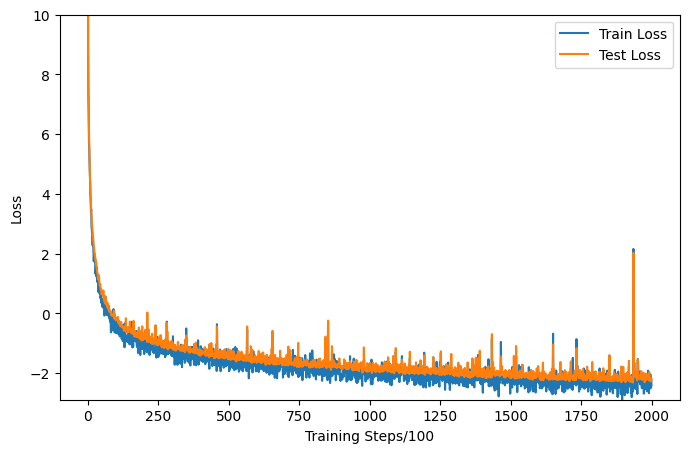

In [42]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_losses, label='Train Loss')
ax.plot(test_losses, label='Test Loss')
ax.set_xlabel('Training Steps/100')
ax.set_ylabel('Loss')
ax.set_ylim(min(train_losses), 10)
ax.legend()
plt.savefig(fig_dir / "training_curve.png")
plt.show()


### Comparison of network output to Monte-Carlo sampling

Kept 157 / 157 flow samples


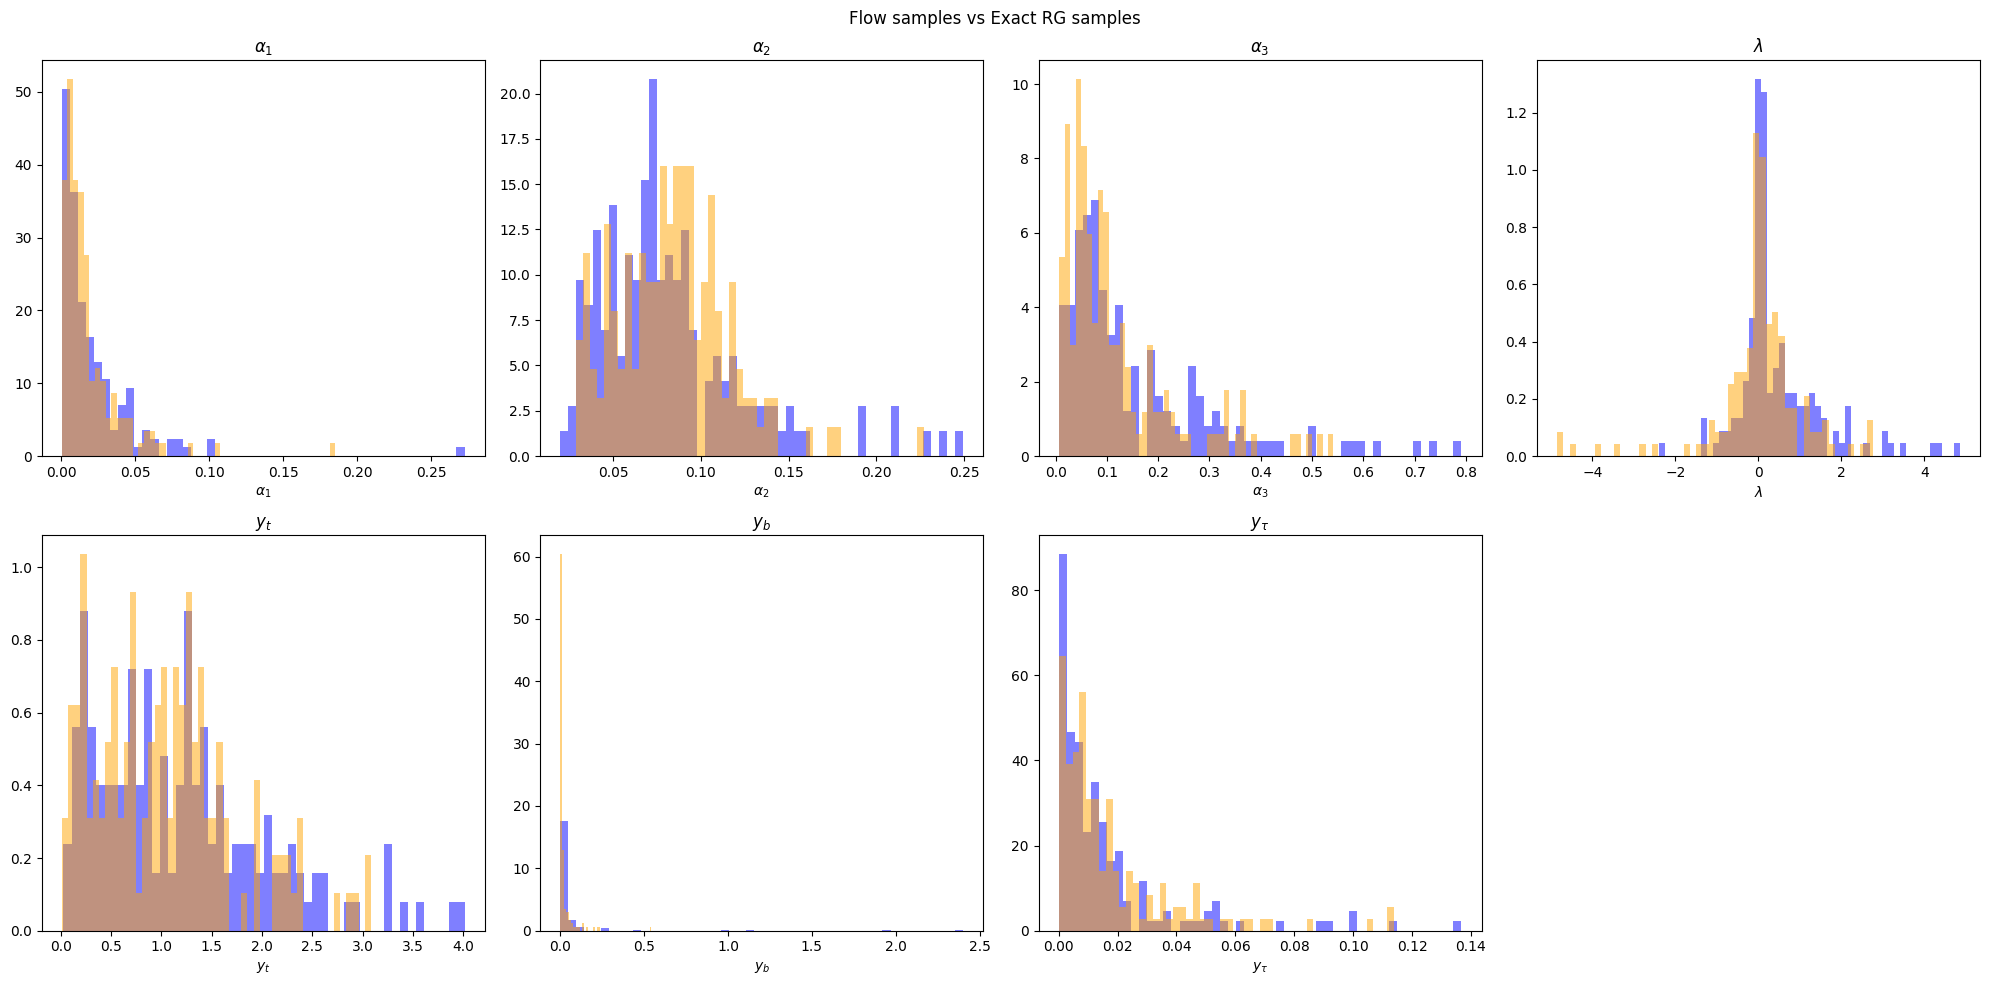

In [43]:
# Picks a model from the test set to compare the flow samples to the exact RG samples
test_indices = [valid_indices[i] for i in perm[split:]]
test_mean, test_chol = jnp.log(uv_means[test_indices[0]]), uv_chols[test_indices[0]] 
test_cond = make_cond(test_mean, test_chol)

# Normalise conditioning vector using training statistics
test_cond_norm = (test_cond - cond_mean) / cond_std

# Generate exact IR samples via Monte Carlo
key, subkey = jax.random.split(key)
exact_samples = generate_ir_samples(subkey, test_mean, test_chol)
exact_samples = valid(exact_samples)

# Generate samples from trained flow via inverse pass
key, subkey = jax.random.split(key)
n_flow_samples = len(exact_samples)
z = jax.random.normal(subkey, (n_flow_samples, n_params))

# Run inverse pass through flow for each sample
flow_samples_norm = vmap(lambda zi: model.apply(best_params, zi, test_cond_norm, jnp.zeros(()), reverse=True))(z)[0]  # [0] to get z, discard ldj

# Denormalise back to physical units and re-exponentiates the gauge couplings
flow_samples_norm = flow_samples_norm * x_std + x_mean
# flow_samples = flow_samples.at[:, :3].set(jnp.exp(flow_samples[:, :3]))
# flow_samples = flow_samples.at[:, 4:].set(jnp.exp(flow_samples[:, 4:]))
flow_samples = np.array(flow_samples_norm, dtype=np.float64)
for i in range(n_params):
    if i == 3:  # skip Higgs quartic — can be negative
        continue
    flow_samples[:, i] = inv_boxcox(flow_samples[:, i], transform_lambdas[i] )

# This applies the same filtering to the output from the flow as we applied to the exact samples, to remove outliers which will bias the statistics
flow_samples = jnp.array(flow_samples)
flow_samples_filtered = valid(flow_samples)
# Prints fraction of samples kept after filtering, should be small for a well-trained network
print(f"Kept {flow_samples_filtered.shape[0]} / {flow_samples.shape[0]} flow samples")

# Plot marginal distributions for each parameter
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes.flatten()[-1].set_visible(False)  # hide unused 8th panel

for i, (ax, name) in enumerate(zip(axes.flatten(), param_names)):
    ax.hist(exact_samples[:, i], bins=50, alpha=0.5, 
            density=True, label='Exact RG', color='blue')
    ax.hist(flow_samples_filtered[:, i], bins=50, alpha=0.5, 
            density=True, label='Flow', color='orange')
    ax.set_xlabel(name)
    ax.set_title(name)

# axes[0].legend()
plt.suptitle('Flow samples vs Exact RG samples')
plt.tight_layout()
plt.savefig(fig_dir / "flow_vs_exact.png")
plt.show()


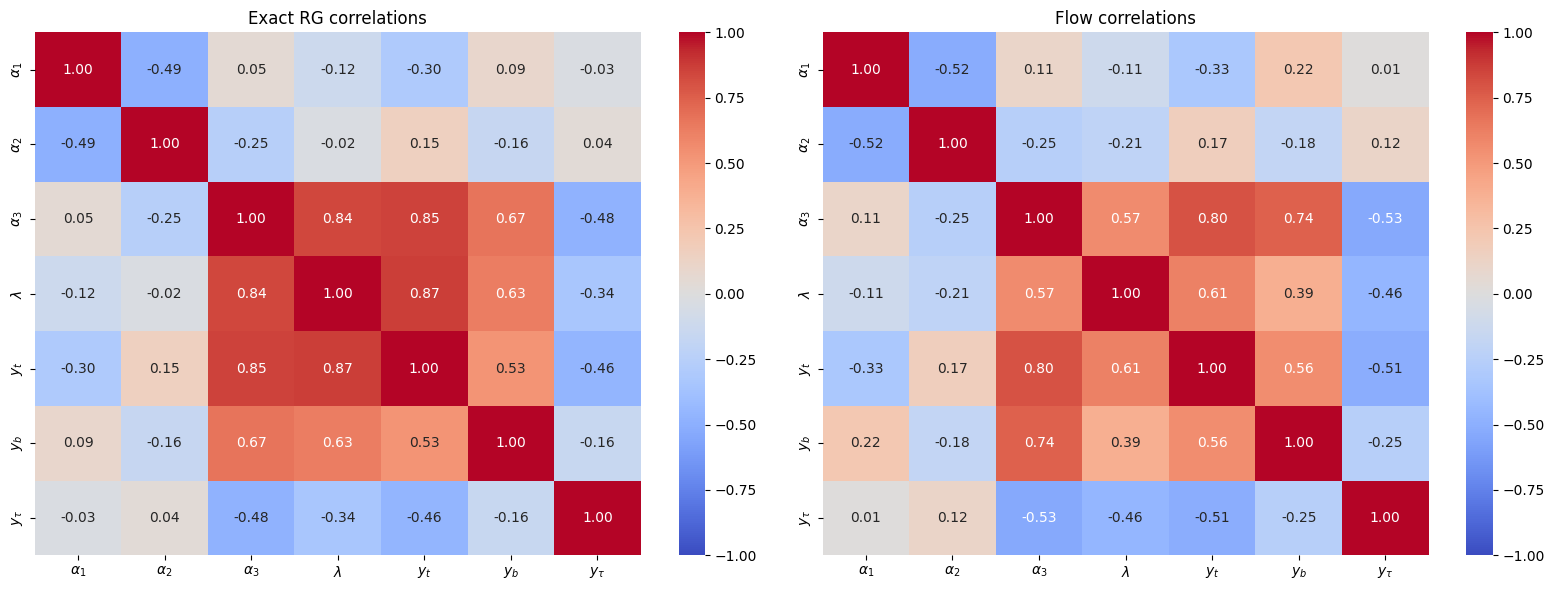

In [44]:
# Compare correlations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_exact = pd.DataFrame(np.array(exact_samples), columns=param_names)
df_flow = pd.DataFrame(np.array(flow_samples_filtered), columns=param_names)

sns.heatmap(df_exact.corr(), ax=axes[0], vmin=-1, vmax=1, 
            cmap='coolwarm', annot=True, fmt='.2f')
axes[0].set_title('Exact RG correlations')

sns.heatmap(df_flow.corr(), ax=axes[1], vmin=-1, vmax=1, 
            cmap='coolwarm', annot=True, fmt='.2f')
axes[1].set_title('Flow correlations')

plt.tight_layout()
plt.savefig(fig_dir / "correlation_comparison.png")
plt.show()

We can now compare the time taken to generate samples and run via RG flow to the time taken to invert the normalising flow and compute an IR distribution. It is not an entirely fair comparison because generate_ir_samples samples the UV and then runs to the IR, while the flow just does the running, but sampling a gaussian is fast compared to the ODE solver, so the 3.9x figure is a fair representation of the speedup. This is because we are doing 2-loop running, if we worked to 1-loop then the difference is much smaller. As the complexity of the ODE integration increases (by including higher loops, more couplings, threshold corrections), the speedup gets larger as the time taken to implement the flow algorithm stays constant while the ODE slows down

In [47]:
# Adds extra elements so z has the same number of samples as the exact RG samples, to ensure a fair speed comparison
z = jnp.concatenate([z, z])[:200]

# JIT compile the sampling functions to get accurate timing, and run once to trigger compilation
_ = generate_ir_samples(subkey, test_mean, test_chol)
_ = vmap(lambda zi: model.apply(best_params, zi, test_cond_norm, jnp.zeros(()), reverse=True))(z)[0].block_until_ready()

n_runs = 10
exact_times = []
flow_times = []
for _ in range(n_runs):
    # Times the Monte-Carlo sampling and then running to the IR via RG evolution
    start = time.time()
    exact_samples = generate_ir_samples(subkey, test_mean, test_chol)
    exact_samples.block_until_ready()         # JAX dispatches operations asynchronously, so without block_until_ready() time.time() would stop before the computation finishes, making the RG evolution look unrealistically fast
    exact_times.append(time.time() - start)
    
    # Times sampling from the flow via inverse pass
    start = time.time()
    flow_samples = vmap(lambda zi: model.apply(best_params, zi, test_cond_norm, jnp.zeros(()), reverse=True))(z)[0]
    flow_samples.block_until_ready()           # JAX dispatches operations asynchronously, so without block_until_ready() time.time() would stop before the computation finishes, making the flow look unrealistically fast
    flow_times.append(time.time() - start)

print(f"Exact: {np.mean(exact_times):.3f} ± {np.std(exact_times):.3f}s")
print(f"Flow:  {np.mean(flow_times):.3f} ± {np.std(flow_times):.3f}s")
print(f"Speedup: {np.mean(exact_times)/np.mean(flow_times):.1f}x")

Exact: 0.533 ± 0.057s
Flow:  0.057 ± 0.006s
Speedup: 9.4x
